In [1]:
import pandas as pd   
import matplotlib.pyplot as plt
import numpy as np
import gc 
import seaborn as sns
import warnings
import lightgbm as lgb
from sklearn.metrics import mean_squared_log_error

#### Create frames and merge them

In [2]:
train = pd.read_csv("../data/train.csv", parse_dates=["timestamp"])
test = pd.read_csv("../data/test.csv", parse_dates=["timestamp"])
weather_train = pd.read_csv("../data/weather_train.csv", parse_dates=["timestamp"])
weather_test = pd.read_csv("../data/weather_test.csv", parse_dates=["timestamp"])
building_metadata = pd.read_csv("../data/building_metadata.csv")

train = train.merge(building_metadata, on='building_id', how='left')
test = test.merge(building_metadata, on='building_id', how='left')
train = train.merge(weather_train, on=['site_id', 'timestamp'], how='left')
test = test.merge(weather_test, on=['site_id', 'timestamp'], how='left')

train["timestamp"] = pd.to_datetime(train["timestamp"])
test["timestamp"] = pd.to_datetime(test["timestamp"])


### Memory reduction        

In [3]:
import pandas as pd
from pandas.api.types import (
    is_datetime64_any_dtype,
    is_categorical_dtype,
    is_integer_dtype,
    is_float_dtype,
    is_object_dtype,
    is_string_dtype,
)

def reduce_mem_usage(df, use_float16=False):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage of dataframe is {start_mem:.2f} MB")

    for col in df.columns:
        s = df[col]
        dtype = s.dtype

        if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
            continue

        if is_integer_dtype(dtype):
            df[col] = pd.to_numeric(s, downcast="integer")

        elif is_float_dtype(dtype):
            if use_float16:
                c_min = s.min()
                c_max = s.max()
                if c_min >= np.finfo(np.float16).min and c_max <= np.finfo(np.float16).max:
                    df[col] = s.astype(np.float16)
                else:
                    df[col] = pd.to_numeric(s, downcast="float")
            else:
                df[col] = pd.to_numeric(s, downcast="float")

        elif is_object_dtype(dtype) or is_string_dtype(dtype):
            df[col] = s.astype("category")

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage after optimization is: {end_mem:.2f} MB")
    print(f"Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%")

    return df

In [4]:
reduce_mem_usage(train)
reduce_mem_usage(test)

Memory usage of dataframe is 3650.12 MB


C:\Users\eEren\AppData\Local\Temp\ipykernel_6572\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
C:\Users\eEren\AppData\Local\Temp\ipykernel_6572\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
C:\Users\eEren\AppData\Local\Temp\ipykernel_6572\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
C:\Users\eEren\AppData\Local\Temp\ipykernel_6572\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.Ca

Memory usage after optimization is: 1176.06 MB
Decreased by 67.8%
Memory usage of dataframe is 7530.36 MB


C:\Users\eEren\AppData\Local\Temp\ipykernel_6572\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
C:\Users\eEren\AppData\Local\Temp\ipykernel_6572\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
C:\Users\eEren\AppData\Local\Temp\ipykernel_6572\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_datetime64_any_dtype(s) or is_categorical_dtype(dtype):
C:\Users\eEren\AppData\Local\Temp\ipykernel_6572\74795618.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.Ca

Memory usage after optimization is: 2266.66 MB
Decreased by 69.9%


,row_id,building_id,meter,timestamp,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,0,2017-01-01 00:00:00,0,Education,7432,2008.0,NaN,17.799999,4.0,11.7,NaN,1021.400024,100.0,3.6
1,1,1,0,2017-01-01 00:00:00,0,Education,2720,2004.0,NaN,17.799999,4.0,11.7,NaN,1021.400024,100.0,3.6
2,2,2,0,2017-01-01 00:00:00,0,Education,5376,1991.0,NaN,17.799999,4.0,11.7,NaN,1021.400024,100.0,3.6
3,3,3,0,2017-01-01 00:00:00,0,Education,23685,2002.0,NaN,17.799999,4.0,11.7,NaN,1021.400024,100.0,3.6
4,4,4,0,2017-01-01 00:00:00,0,Education,116607,1975.0,NaN,17.799999,4.0,11.7,NaN,1021.400024,100.0,3.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41697595,41697595,1444,0,2018-05-09 07:00:00,15,Entertainment/public assembly,19619,1914.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41697596,41697596,1445,0,2018-05-09 07:00:00,15,Education,4298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41697597,41697597,1446,0,2018-05-09 07:00:00,15,Entertainment/public assembly,11265,1997.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41697598,41697598,1447,0,2018-05-09 07:00:00,15,Lodging/residential,29775,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
del weather_train, weather_test, building_metadata
gc.collect()

0

In [6]:
def check_columns_are_same(df1, df2):
    
    cols1 = set(df1.columns)
    cols2 = set(df2.columns)
    if cols1 == cols2:
        print("Columns are the same in both dataframes.")
    else:
        print("Columns differ between the two dataframes.")
        print(f"Columns in train but not in test:", cols1 - cols2)
        print(f"Columns in test but not in train:", cols2 - cols1)

In [7]:
check_columns_are_same(train, test)

Columns differ between the two dataframes.
Columns in train but not in test: {'meter_reading'}
Columns in test but not in train: {'row_id'}


#### Feature Engineering 

In [8]:
## Drop some features that are not useful for modeling
train["building_age"] = train["timestamp"].dt.year - train["year_built"]
test["building_age"] = test["timestamp"].dt.year - test["year_built"]

train.drop(columns=["floor_count","year_built","cloud_coverage","wind_direction"], inplace=True)
test.drop(columns=["floor_count","year_built","cloud_coverage","wind_direction"], inplace=True)


In [9]:
## Fill missing values with mean 

train["building_age"] = train["building_age"].fillna(train["building_age"].mean())
test["building_age"] = test["building_age"].fillna(train["building_age"].mean())

train["wind_speed"] = train["wind_speed"].fillna(train["wind_speed"].mean())
test["wind_speed"] = test["wind_speed"].fillna(train["wind_speed"].mean())

train["precip_depth_1_hr"] = train["precip_depth_1_hr"].fillna(train["precip_depth_1_hr"].mean())
test["precip_depth_1_hr"] = test["precip_depth_1_hr"].fillna(train["precip_depth_1_hr"].mean())

train["sea_level_pressure"] = train["sea_level_pressure"].fillna(train["sea_level_pressure"].mean())
test["sea_level_pressure"] = test["sea_level_pressure"].fillna(train["sea_level_pressure"].mean())


In [10]:
def interpolate_weather_by_site(df, columns):
    df.sort_values(["site_id", "timestamp"], inplace=True)

    for col in columns:
        df[col] = df.groupby("site_id")[col].transform(
            lambda s: s.interpolate(method="linear", limit_direction="both")
        )

    return df

interpolate_cols = [
    "air_temperature",
    "dew_temperature",
]

train = interpolate_weather_by_site(train, interpolate_cols)
test = interpolate_weather_by_site(test, interpolate_cols)

In [11]:
train.isnull().sum() / len(train) * 100

building_id           0.0
meter                 0.0
timestamp             0.0
meter_reading         0.0
site_id               0.0
primary_use           0.0
square_feet           0.0
air_temperature       0.0
dew_temperature       0.0
precip_depth_1_hr     0.0
sea_level_pressure    0.0
wind_speed            0.0
building_age          0.0
dtype: float64

In [12]:
## Extract time-based features from timestamp

train["hour"] = train["timestamp"].dt.hour
train["day"] = train["timestamp"].dt.day
train["month"] = train["timestamp"].dt.month
train["year"] = train["timestamp"].dt.year

test["hour"] = test["timestamp"].dt.hour
test["day"] = test["timestamp"].dt.day
test["month"] = test["timestamp"].dt.month
test["year"] = test["timestamp"].dt.year



In [13]:
## Drop timestamp as we have extracted features from it
train.drop(columns=["timestamp"], inplace=True)
test.drop(columns=["timestamp"], inplace=True)


### Model Training  

In [14]:
train.columns

Index(['building_id', 'meter', 'meter_reading', 'site_id', 'primary_use',
       'square_feet', 'air_temperature', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_speed', 'building_age',
       'hour', 'day', 'month', 'year'],
      dtype='str')

In [15]:
feature_cols = [
    "building_id",
    "meter",
    "site_id",
    "primary_use",
    "square_feet",
    "air_temperature",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_speed",
    "building_age",
    "hour",
    "day",
    "month",
    "year",
]

target_col = "meter_reading"
cat_cols = ["building_id", "meter", "site_id", "primary_use"]

In [16]:
split_idx = int(len(train) * 0.8)

train_sorted = train.sort_values(["year", "month", "day", "hour"])

train_part = train_sorted.iloc[:split_idx]
valid_part = train_sorted.iloc[split_idx:]

X_train = train_part[feature_cols]
y_train = train_part[target_col]

X_valid = valid_part[feature_cols]
y_valid = valid_part[target_col]

for col in cat_cols:
    train_sorted[col] = train_sorted[col].astype("category")




In [17]:
params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "seed": 42,
    "verbosity": -1,
}


### LightGBM model training

In [18]:
train_dataset = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols, free_raw_data=False)
valid_dataset = lgb.Dataset(X_valid, label=y_valid, categorical_feature=cat_cols, free_raw_data=False)

model = lgb.train(
    params,
    train_dataset,
    valid_sets=[train_dataset, valid_dataset],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(100),
    ],
)

Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 31037	valid_1's rmse: 56535.3
Early stopping, best iteration is:
[7]	training's rmse: 129570	valid_1's rmse: 54644.7


In [19]:
valid_pred = model.predict(X_valid, num_iteration=model.best_iteration)
valid_pred = np.clip(valid_pred, 0, None)
rmsle = np.sqrt(mean_squared_log_error(y_valid, valid_pred))
print(f"Validation RMSLE: {rmsle:.4f}")


Validation RMSLE: 3.9251


### DEBUG Phase

In [20]:
pred_df = valid_part[["meter_reading","meter"]].copy()
pred_df["pred_meter"] = valid_pred

pred_df.info()

<class 'pandas.DataFrame'>
Index: 4043220 entries, 16172880 to 20216099
Data columns (total 3 columns):
 #   Column         Dtype  
---  ------         -----  
 0   meter_reading  float64
 1   meter          int8   
 2   pred_meter     float64
dtypes: float64(2), int8(1)
memory usage: 96.4 MB


In [31]:
pred_df["pred_meter"].unique().size   ## 44 tane    farlı değer var.

44

In [32]:
pred_df.groupby("meter")["pred_meter"].nunique()

meter
0     2
1     1
2    43
3     1
Name: pred_meter, dtype: int64

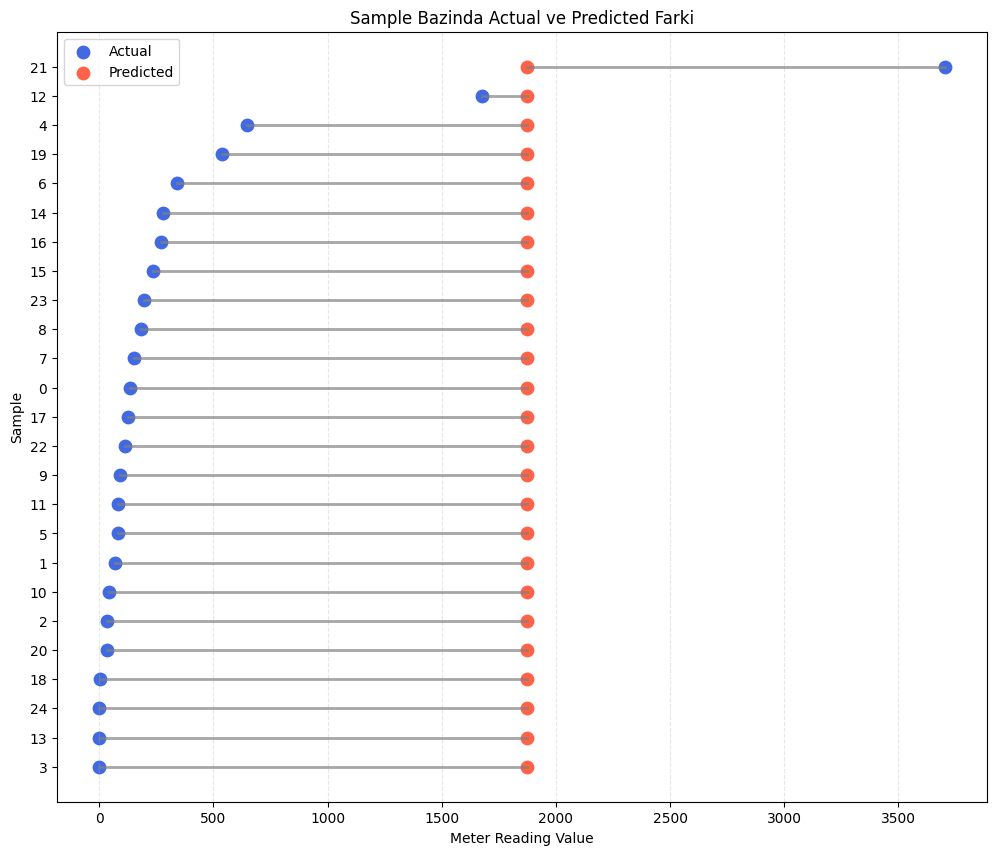

In [30]:
sample_df = pred_df.sample(25, random_state=42).reset_index(drop=True)
sample_df["sample_id"] = sample_df.index.astype(str)
sample_df = sample_df.sort_values("meter_reading").reset_index(drop=True)

plt.figure(figsize=(12, 10))

for i, row in sample_df.iterrows():
    plt.plot(
        [row["meter_reading"], row["pred_meter"]],
        [i, i],
        color="gray",
        alpha=0.7,
        linewidth=2,
    )

plt.scatter(
    sample_df["meter_reading"],
    range(len(sample_df)),
    color="royalblue",
    s=80,
    label="Actual",
)

plt.scatter(
    sample_df["pred_meter"],
    range(len(sample_df)),
    color="tomato",
    s=80,
    label="Predicted",
)

plt.yticks(range(len(sample_df)), sample_df["sample_id"])
plt.xlabel("Meter Reading Value")
plt.ylabel("Sample")
plt.title("Sample Bazinda Actual ve Predicted Farki")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.show()